In [48]:
import scanpy as sc

In [49]:
adata=sc.read_h5ad('./brain_small.h5ad')

Quality Control

In [ ]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [51]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

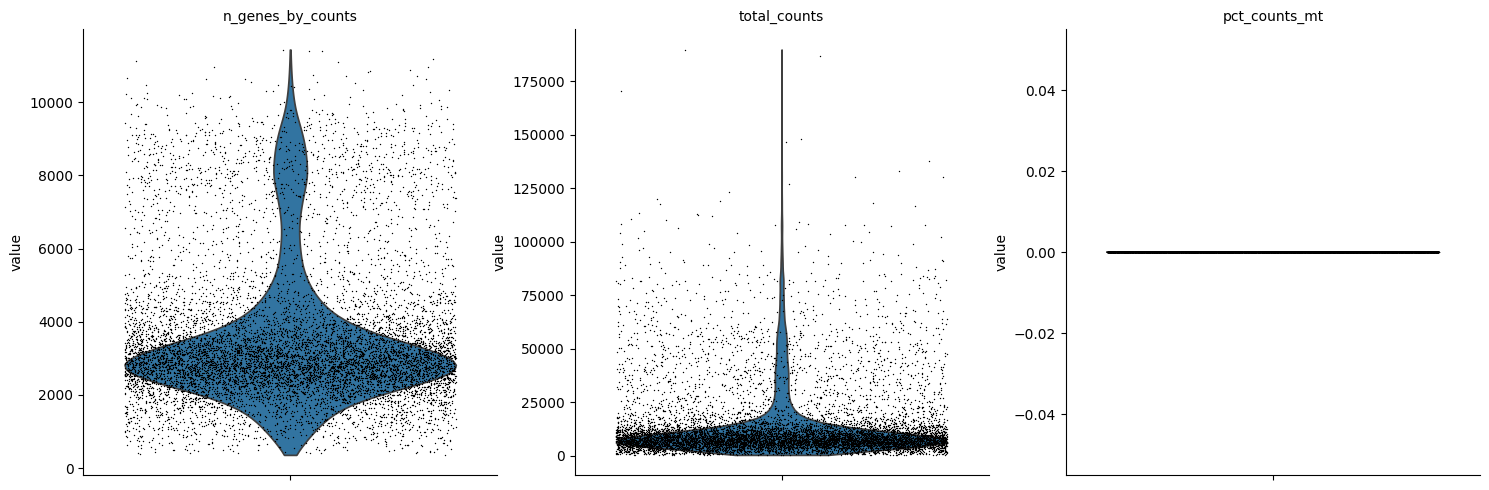

In [52]:
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"], jitter=0.4, multi_panel=True)

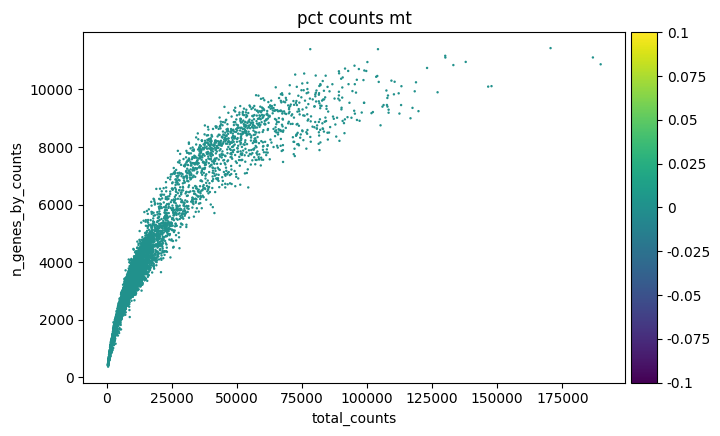

In [53]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [54]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

Doublet detection

In [ ]:
#sc.pp.scrublet(adata, batch_key="orig.ident")

Normalization

In [55]:
adata.layers["counts"] = adata.X.copy()

In [56]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

Feature selection

In [57]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="orig.ident")

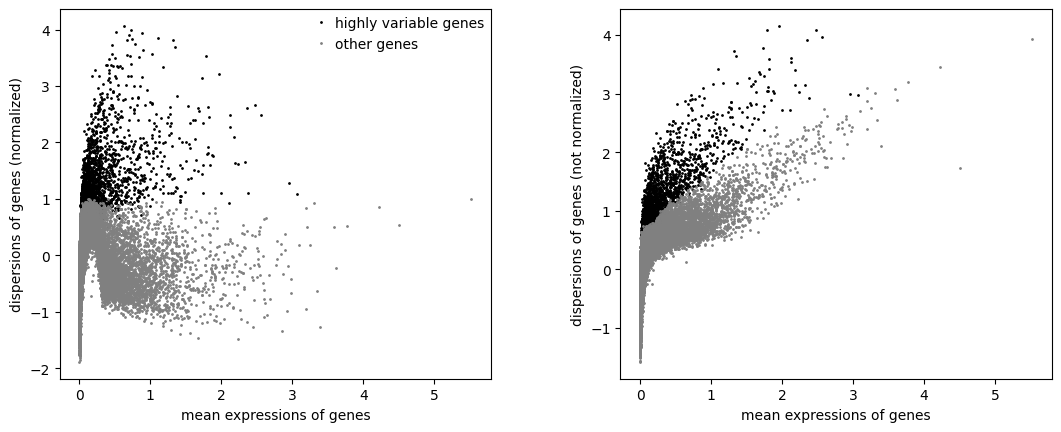

In [58]:
sc.pl.highly_variable_genes(adata)

Dimensionality Reduction

In [59]:
sc.tl.pca(adata)

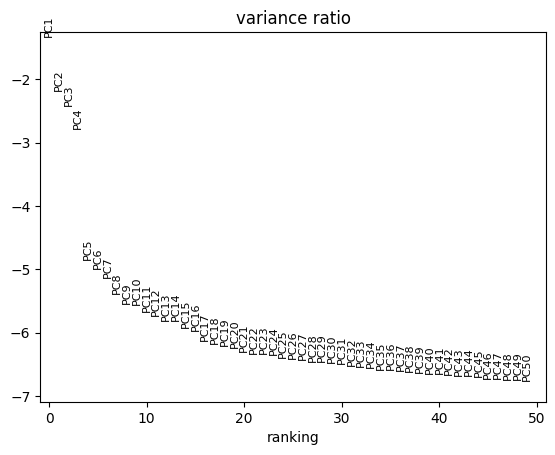

In [60]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

Visualization

In [61]:
sc.pp.neighbors(adata)

In [62]:
sc.tl.umap(adata)

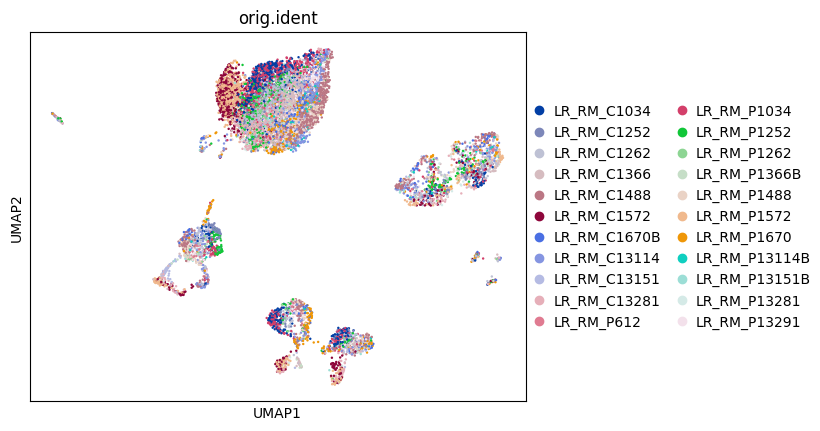

In [63]:
sc.pl.umap(adata, color="orig.ident")

Clustering

In [64]:
sc.tl.leiden(adata, flavor="igraph")

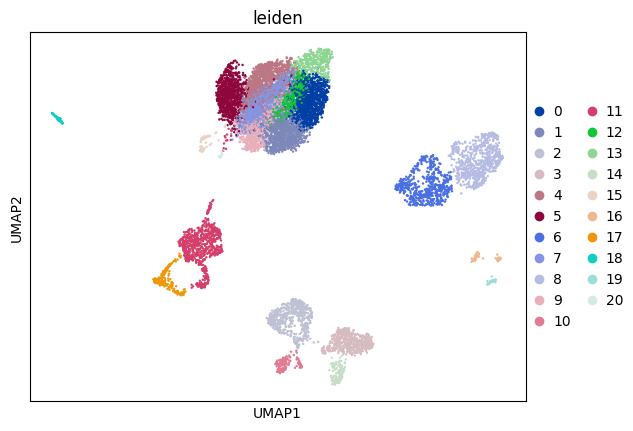

In [65]:
sc.pl.umap(adata, color=["leiden"])

Re-assess quality control and cell filtering

In [ ]:
# adata.obs["predicted_doublet"] = adata.obs["predicted_doublet"].astype("category")
# sc.pl.umap(
#     adata,
#     color=["leiden", "predicted_doublet", "doublet_score"],
#     # increase horizontal space between panels
#     wspace=0.5,
# )


In [ ]:
#adata = adata[~adata.obs["predicted_doublet"].to_numpy()].copy()

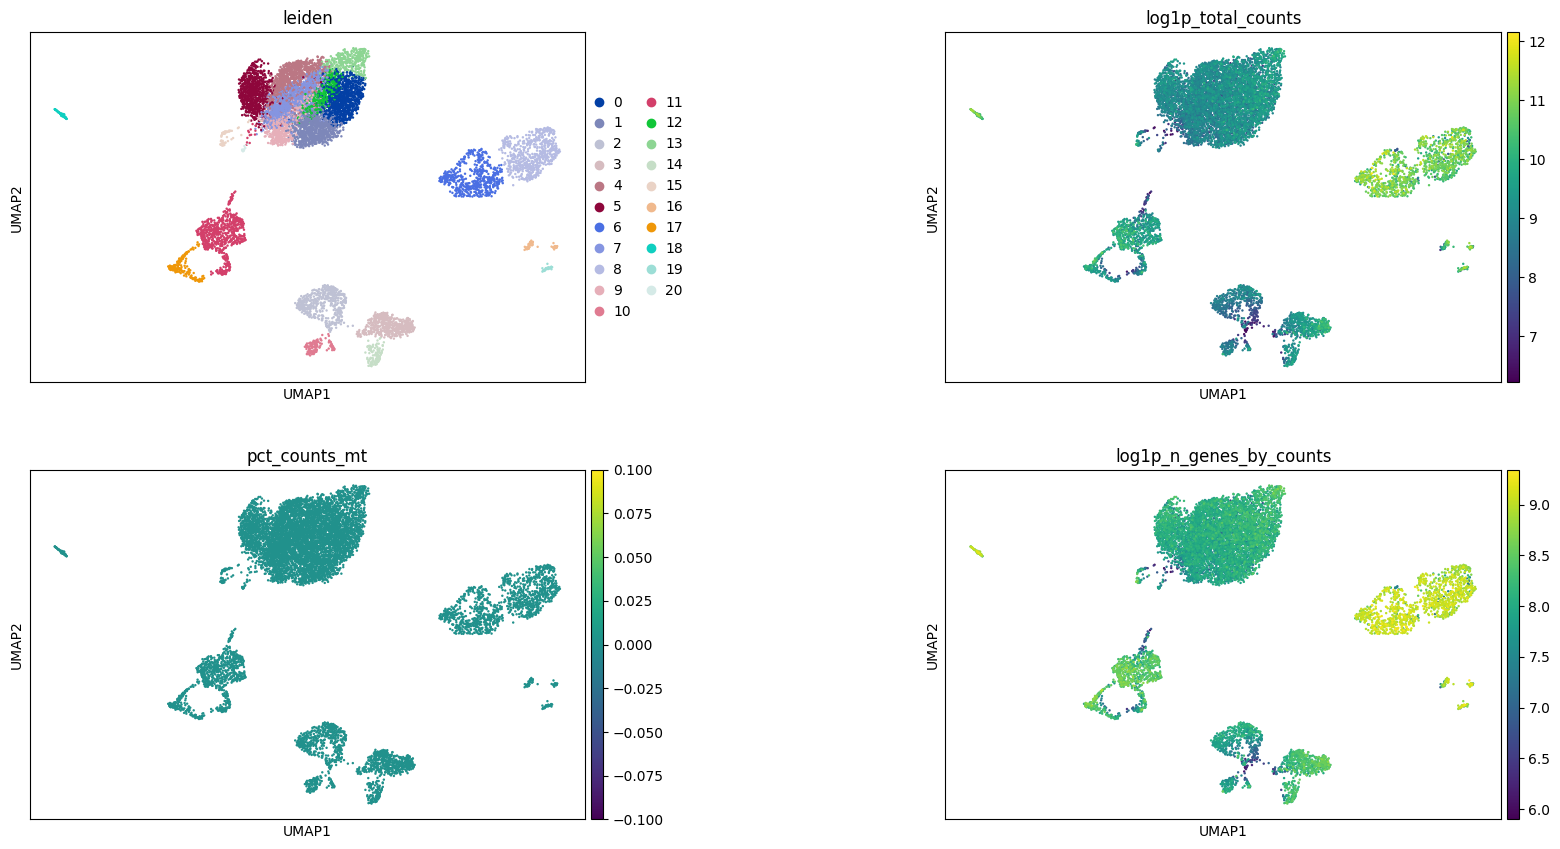

In [68]:
sc.pl.umap(
    adata, color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"], wspace=0.5, ncols=2
)

Cell-type annotation - resolution 1.5

In [69]:
import celltypist as ct
import decoupler as dc

In [70]:
sc.tl.leiden(adata, flavor="igraph", key_added="leiden_res1.5", resolution=1.5)

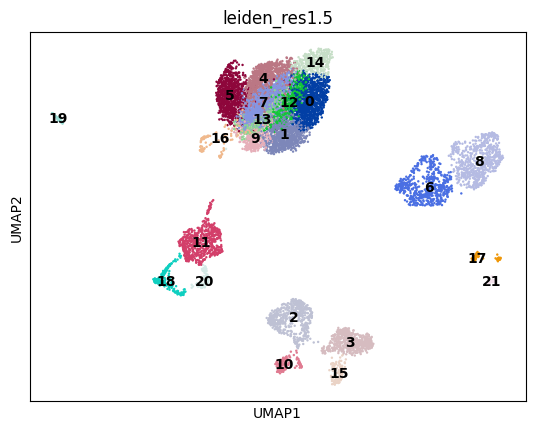

In [71]:
sc.pl.umap(
    adata,
    color=["leiden_res1.5"],
    legend_loc="on data",
)

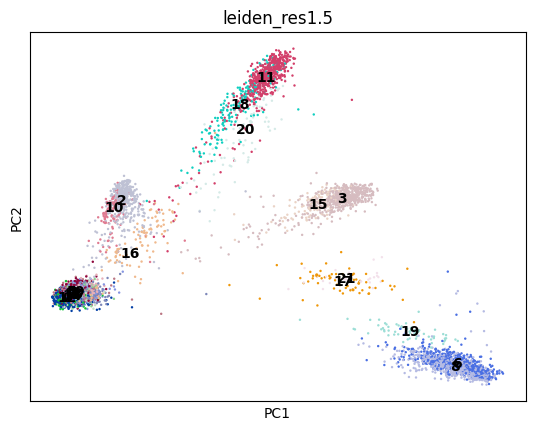

In [74]:
sc.pl.pca(
    adata,
    color=["leiden_res1.5"],
    legend_loc="on data",
)

Differentially-expressed Genes as Markers

In [72]:
sc.tl.rank_genes_groups(adata, groupby="leiden_res1.5")
sc.tl.filter_rank_genes_groups(adata, min_fold_change=1.5)

/home/whalstj1/2025-bioinformatics/202255180/week10/.venv/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/whalstj1/2025-bioinformatics/202255180/week10/.venv/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/whalstj1/2025-bioinformatics/202255180/week10/.venv/lib/pyt

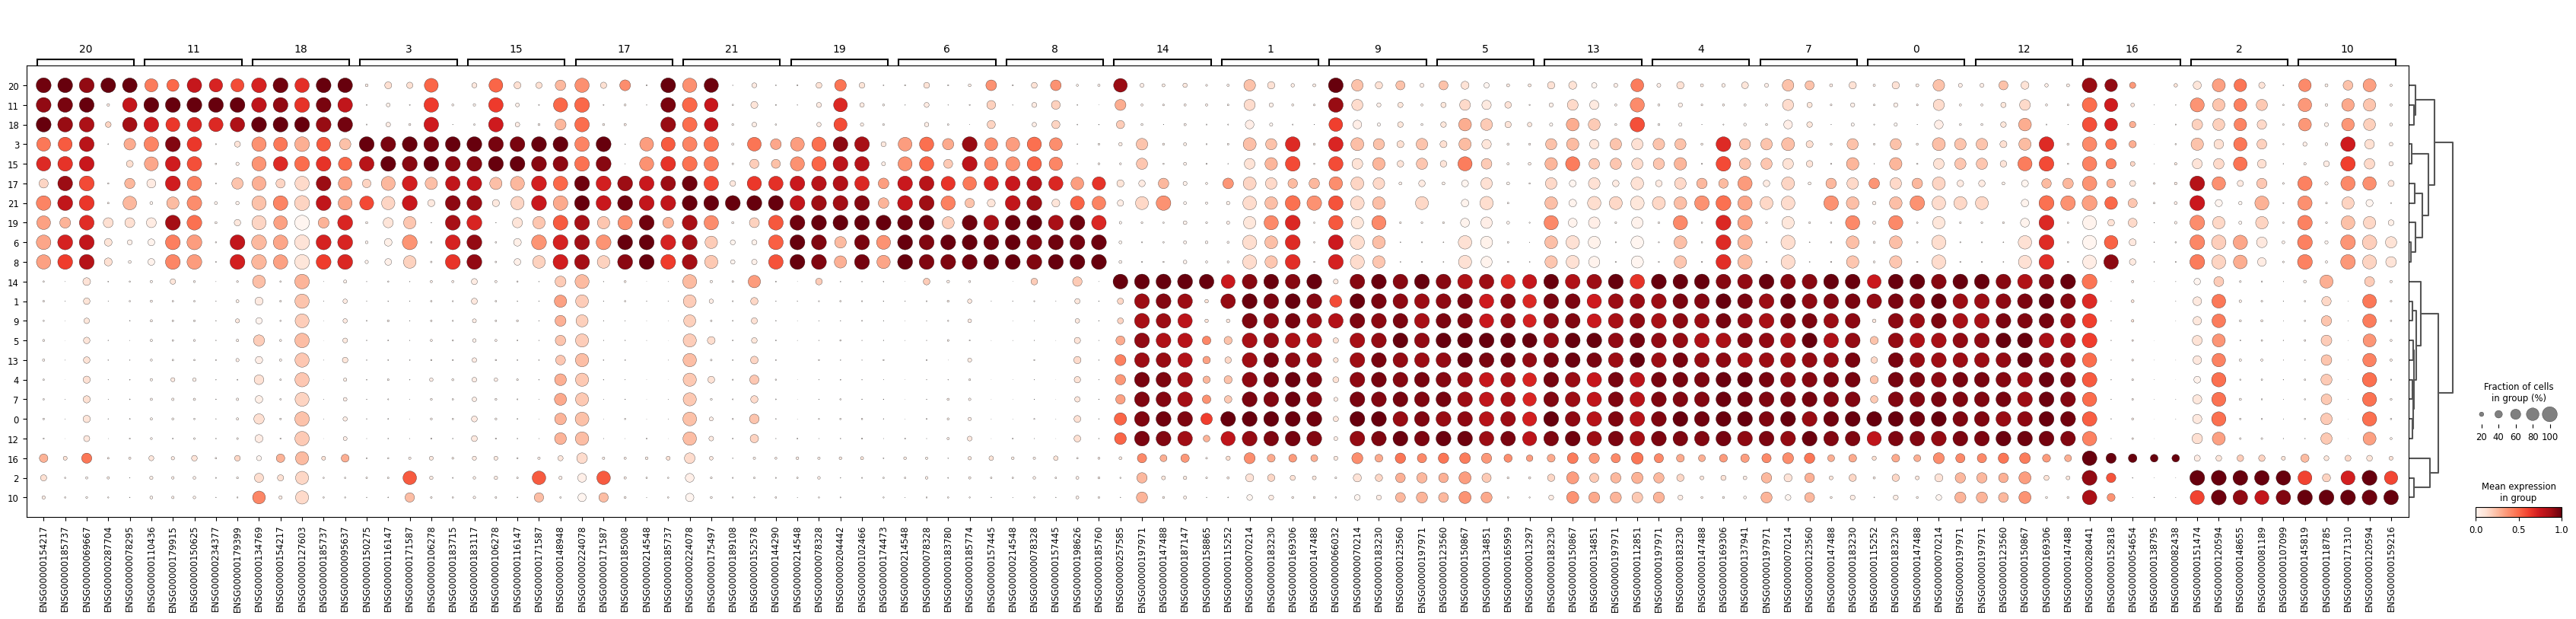

In [73]:
sc.pl.rank_genes_groups_dotplot(adata, groupby="leiden_res1.5", standard_scale="var", n_genes=5)